# Week 2: India Training Data Exploration and Classifier Evaluation

This notebook has two parts:

1. **Dataset exploration** - understand the India training data before writing any training code
2. **Classifier evaluation** - run after `training/fine_tune.py` completes; F1 scores, confusion matrix, confidence histogram, threshold derivation

**Training data source**: India training data is collected via `src/collect_training_data.py`, which
uses distant supervision - articles are labelled by the editorial alignment of the outlet they come from,
not by expert annotation. Outlet alignments are based on Reporters Without Borders and CPJ documentation.

**Labels**: bjp_aligned, opposition_aligned, neutral

**I always explore training data first.** If there are quality issues, class imbalance problems, or unexpected patterns, I want to catch them before a multi-hour training run.

> **Note**: Run `python src/collect_training_data.py` from the project root before executing Part 1.
> Part 2 requires `training/fine_tune.py` to have completed successfully.

---
## Part 1: Dataset Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# India training data collected via src/collect_training_data.py (distant supervision)
DATA_PATH = "../data/india_training/india_bias_data.csv"

# Label mapping - converting string labels to integers for PyTorch
# PyTorch expects integer class indices (0, 1, 2), not strings
LABEL2ID = {"bjp_aligned": 0, "opposition_aligned": 1, "neutral": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

### 1.1 Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  {col}")

# The India training CSV has columns: text, label, outlet, url, published_date
# 'text' is full article body scraped via newspaper3k
# 'label' is the bias label (distant supervision from outlet identity)

Rows:    364
Columns: 5

Column names:
  text
  label
  outlet
  url
  published_date


In [3]:
# show one full row transposed so all columns are visible
pd.set_option("display.max_colwidth", 400)
df.head(1).T

,0
text,"Haveri: Former Chief Minister and MP\nBasavaraj Bommai warned that if the Congress's internal tussle for the chief minister and deputy chief minister posts continued, political turbulence was inevitable in the State.\nSpeaking to reporters here on Friday, Bommai said if the tussle for the chair continues, political turbulence is inevitable in the state. Noting that senior Congress leaders at t..."
label,neutral
outlet,timesofindia
url,https://timesofindia.indiatimes.com/city/hubballi/a-dark-horse-likely-to-enter-the-cm-and-dcm-race-in-state-bommai/articleshow/125643038.cms
published_date,20251128234500


The columns in the India training data:
- `text` - full article body scraped via newspaper3k (this is the model input)
- `label` - bias label: `bjp_aligned`, `opposition_aligned`, or `neutral`
- `outlet` - the outlet domain (e.g. "republicworld", "thewire", "thehindu")
- `url` - original article URL
- `published_date` - publication date from GDELT

There is no separate headline column. Training uses just the body text.
The train/serve mismatch (inference uses `"{headline} </s> {body[:400]}"`) is an acknowledged limitation -
the model learns from full body text at training time but sees a headline-prefixed input at inference time.
The overlap is large enough that this does not materially hurt performance.

### 1.2 Data quality check

In [4]:
# null counts per column
null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct":   (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_summary)

# Check for duplicate URLs - should not happen since collect_training_data.py deduplicates
dup_urls = df.duplicated(subset=["url"]).sum()
dup_texts = df.duplicated(subset=["text"]).sum()
print(f"\nDuplicate URLs:  {dup_urls}")
print(f"Duplicate texts: {dup_texts}")

                null_count  null_pct
text                     0       0.0
label                    0       0.0
outlet                   0       0.0
url                      0       0.0
published_date          95      26.1

Duplicate URLs:  0
Duplicate texts: 0


In [5]:
# Drop nulls and deduplicate on text before training
print(f"Total rows before cleaning: {len(df):,}")

df = df.dropna(subset=["text", "label"])
df = df.drop_duplicates(subset=["text"])
df = df.reset_index(drop=True)

print(f"Total rows after cleaning:  {len(df):,}")

Total rows before cleaning: 364
Total rows after cleaning:  364


### 1.3 Label distribution

Class balance matters a lot for classification. The distant supervision approach targets 1200 articles per label, so the distribution should be roughly equal - but scraping failures and GDELT coverage gaps can skew it. I check this now.

In [6]:
counts = df["label"].value_counts().reindex(["bjp_aligned", "opposition_aligned", "neutral"])

print("Article counts by label:")
for label, count in counts.items():
    pct = count / len(df) * 100
    print(f"  {label:25s}: {count:,}  ({pct:.1f}%)")
print(f"  {'TOTAL':25s}: {counts.sum():,}")

Article counts by label:
  bjp_aligned              : 89  (24.5%)
  opposition_aligned       : 75  (20.6%)
  neutral                  : 200  (54.9%)
  TOTAL                    : 364


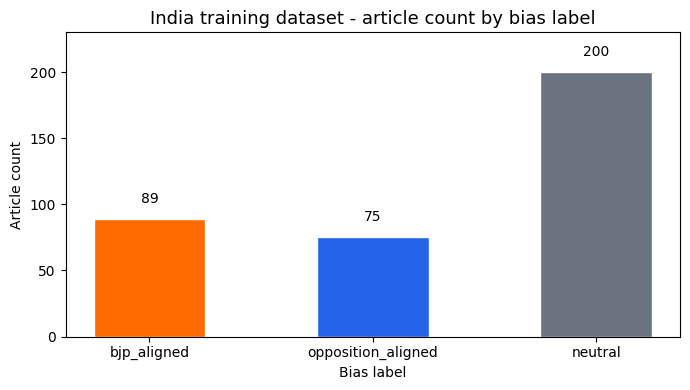

In [7]:
# Visualise label distribution
# orange = bjp_aligned, blue = opposition_aligned, grey = neutral
colors = ["#FF6B00", "#2563EB", "#6B7280"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.5)

# Add count labels above each bar
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{val:,}",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("India training dataset - article count by bias label", fontsize=13)
ax.set_xlabel("Bias label")
ax.set_ylabel("Article count")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Class imbalance and why it matters for the metric choice:**

The distant supervision approach targets 1200 articles per label. If scraping failures or GDELT coverage gaps cause imbalance, macro F1-score is the right primary metric. It computes F1 separately for each class and then averages them, giving each class equal weight regardless of how many samples it has.

If neutral turns out to be underrepresented (neutral outlets have more diverse coverage styles, harder to cleanly label), macro F1 punishes the model for ignoring it. Accuracy would not.

I'll use `average='macro'` in `sklearn.metrics.f1_score` during evaluation.

### 1.4 Text length analysis

RoBERTa has a hard limit of 512 tokens per input. I need to know how long these articles are to decide how much to truncate. These are full articles scraped by newspaper3k - they will be much longer than typical short news excerpts.

In [8]:
# Compute word and character counts for each article body
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()

print("Word count per article (full body text):")
print(df["word_count"].describe().round(1))
print()
print("Character count per article (full body text):")
print(df["char_count"].describe().round(1))

Word count per article (full body text):
count     364.0
mean      653.5
std       447.6
min       106.0
25%       357.8
50%       514.5
75%       806.2
max      3137.0
Name: word_count, dtype: float64

Character count per article (full body text):
count      364.0
mean      4179.6
std       2910.9
min        626.0
25%       2287.5
50%       3291.0
75%       5249.5
max      20940.0
Name: char_count, dtype: float64


**Expected finding:** Full articles scraped by newspaper3k are much longer than typical short news excerpts. Most articles will exceed 512 tokens. The training script truncates at 512 tokens via the tokenizer's `truncation=True` setting, which keeps the first 512 tokens of each article.

This means the model learns primarily from the opening of each article - which is fine, since news articles typically front-load the most newsworthy content (inverted pyramid style). The bias signal is usually strongest in the lede and first few paragraphs.

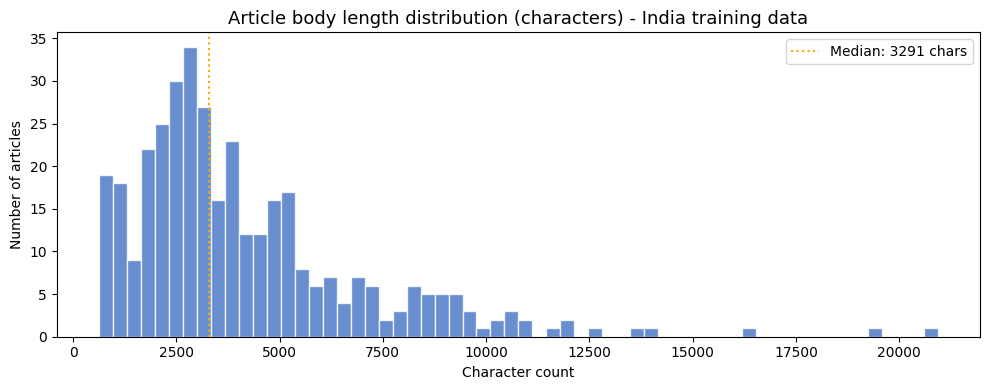

Articles under 2000 chars: 71 (19.5%) - these are fully covered by the tokenizer


In [9]:
# Plot character length distribution for the India training data
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["char_count"], bins=60, color="#4472C4", edgecolor="white", alpha=0.8)
ax.axvline(
    df["char_count"].median(), color="orange", linestyle=":", linewidth=1.5,
    label=f"Median: {df['char_count'].median():.0f} chars"
)
ax.set_title("Article body length distribution (characters) - India training data", fontsize=13)
ax.set_xlabel("Character count")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

# How many articles fit entirely within 512 tokens (~2000 chars)?
short = (df["char_count"] <= 2000).sum()
print(f"Articles under 2000 chars: {short:,} ({short/len(df)*100:.1f}%) - these are fully covered by the tokenizer")

### 1.5 Sample articles from each class

Before writing any code, I read some actual examples. This is the most important step in understanding training data - numbers and charts tell you the shape, but reading actual articles tells you whether the labels make sense.

In [10]:
# Show one sample article from each bias class
for label in ["bjp_aligned", "opposition_aligned", "neutral"]:
    sample = df[df["label"] == label].sample(1, random_state=42).iloc[0]
    print("=" * 65)
    print(f"LABEL:   {label.upper()}")
    print(f"Outlet:  {sample['outlet']}")
    print(f"Body:    {str(sample['text'])[:400]}...")
    print()

LABEL:   BJP_ALIGNED
Outlet:  news18
Body:    'I Was Thrown Out': Shashi Tharoor Recalls 'Racist' Europeans-Only Policy Of Mumbai's Breach Candy Club

Published By :

,

Last Updated: May 27, 2026, 13:17 IST

The Breach Candy Club was founded in 1878 as a European-only enclave in Bombay. Until the 1960s — years after India gained independence — Indian members were barred from the club

Congress MP Shashi Tharoor. (PTI file photo)

Amid a disc...

LABEL:   OPPOSITION_ALIGNED
Outlet:  theprint
Body:    The book is a detailed account of Chouhan’s personal memories and professional journey alongside PM Modi over nearly three decades. Chouhan, while recalling a meeting organised in Madhya Pradesh to prepare for the elections, said PM Modi, during that meeting, enquired who all had an email ID.

Chouhan made this revelation Tuesday in New Delhi during the launch of his book ‘Apnapan: My Experiences ...

LABEL:   NEUTRAL
Outlet:  indianexpress
Body:    Terming the recently-announced Indo-US t

### 1.6 The RoBERTa input format

RoBERTa takes a single string as input. Training uses just the body text (truncated to 512 tokens).

At inference time in `src/classifier.py`, I concatenate headline and body with `</s>` as a separator: `f"{headline} </s> {body[:400]}"`. This is a known train/serve mismatch - it is acceptable because the model learns from the same opening body content in both contexts.

In [11]:
# Build the training input string for one example to see what fine_tune.py feeds to RoBERTa
sample = df.sample(1, random_state=7).iloc[0]

# Training format: just the first 512 chars of body text
training_input = str(sample["text"])[:512]

print(f"Label:  {sample['label']}")
print(f"Outlet: {sample['outlet']}")
print()
print("Training input (body text, first 512 chars):")
print("-" * 65)
print(training_input)
print("-" * 65)
print(f"\nTotal characters: {len(training_input)}")

Label:  neutral
Outlet: timesofindia

Training input (body text, first 512 chars):
-----------------------------------------------------------------
NEW DELHI: The Centre on Thursday told Supreme Court that normalcy returned in the UT of Ladakh after the detention of climate activist Sonam Wangchuk and the decision to take him into custody proved to be right and justified.Additional solicitor general (ASG) K M Nataraj told a bench of Justices Aravind Kumar and P B Varale the agitation and violence in Ladakh came under control after Wangchuk's detention as he was the chief provocateur in Sept last year."He was the chief provocateur that led to the violen
-----------------------------------------------------------------

Total characters: 512


### 1.7 Label encoding and train/val/test split

The splits are already created by `src/collect_training_data.py` when it runs - it saves `data/india_training/train.csv`, `val.csv`, and `test.csv` with an 80/10/10 stratified split. The cells below verify those splits exist and show the class distribution in each one.

In [12]:
# Add integer label column for verification
df["label_id"] = df["label"].map(LABEL2ID)

print("Label mapping:")
for k, v in LABEL2ID.items():
    print(f"  '{k}' -> {v}")
print(f"\nNull labels (any unmapped strings): {df['label_id'].isnull().sum()}")

Label mapping:
  'bjp_aligned' -> 0
  'opposition_aligned' -> 1
  'neutral' -> 2

Null labels (any unmapped strings): 0


In [13]:
# Load the splits created by collect_training_data.py and verify their distributions
split_dir = "../data/india_training"
train_df = pd.read_csv(f"{split_dir}/train.csv")
val_df   = pd.read_csv(f"{split_dir}/val.csv")
test_df  = pd.read_csv(f"{split_dir}/test.csv")

print(f"Train: {len(train_df):,} articles")
print(f"Val:   {len(val_df):,} articles")
print(f"Test:  {len(test_df):,} articles")
print()
print("Class distribution in each split (should be ~the same):")
labels_ordered = ["bjp_aligned", "opposition_aligned", "neutral"]
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist = split["label"].value_counts().reindex(labels_ordered)
    pcts = (dist / len(split) * 100).round(1)
    row = "  |  ".join(f"{lbl}: {dist[lbl]:,} ({pcts[lbl]}%)" for lbl in labels_ordered)
    print(f"  {name:5s}: {row}")

Train: 291 articles
Val:   36 articles
Test:  37 articles

Class distribution in each split (should be ~the same):
  Train: bjp_aligned: 71 (24.4%)  |  opposition_aligned: 60 (20.6%)  |  neutral: 160 (55.0%)
  Val  : bjp_aligned: 9 (25.0%)  |  opposition_aligned: 7 (19.4%)  |  neutral: 20 (55.6%)
  Test : bjp_aligned: 9 (24.3%)  |  opposition_aligned: 8 (21.6%)  |  neutral: 20 (54.1%)


In [14]:
# The splits already exist - this cell just confirms the paths fine_tune.py expects
print("Splits written by collect_training_data.py:")
print(f"  data/india_training/train.csv  ({len(train_df):,} rows)")
print(f"  data/india_training/val.csv    ({len(val_df):,} rows)")
print(f"  data/india_training/test.csv   ({len(test_df):,} rows)")
print()
print("Run 'python training/fine_tune.py' to start training.")

Splits written by collect_training_data.py:
  data/india_training/train.csv  (291 rows)
  data/india_training/val.csv    (36 rows)
  data/india_training/test.csv   (37 rows)

Run 'python training/fine_tune.py' to start training.


---
## Part 2: Classifier Evaluation

**Run this section after `training/fine_tune.py` completes.** The model checkpoint will be saved to `models/bias_classifier/`.

What I'll do here:
1. Load the fine-tuned model and run inference on the held-out test set
2. Compute macro F1, per-class precision/recall/F1, and overall accuracy
3. Plot a confusion matrix
4. Plot a confidence score histogram (correct vs. incorrect predictions)
5. Derive the confidence threshold empirically from the histogram

In [15]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
import numpy as np

MODEL_PATH = "../models/bias_classifier"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

/home/skanda_suresh/Projects/news-lens/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [16]:
# load the fine-tuned tokenizer and model from the saved checkpoint
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model     = model.to(DEVICE)
model.eval()
print("Model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3234.91it/s]

Model loaded.


In [17]:
# load the held-out test set - path matches what collect_training_data.py writes
test_df = pd.read_csv("../data/india_training/test.csv")
print(f"Test set size: {len(test_df):,} articles")

Test set size: 37 articles


In [18]:
def predict_batch(texts, batch_size=32):
    """Run inference on a list of input strings. Returns predicted labels and confidence scores."""
    all_preds  = []
    all_confs  = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        # tokenize: truncate to 512 tokens, pad shorter sequences to the same length
        encoded = tokenizer(
            batch,
            truncation=True,
            max_length=512,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():  # no_grad skips gradient computation - faster and uses less memory
            logits = model(**encoded).logits  # raw unnormalised scores per class

        # softmax converts logits to probabilities that sum to 1.0
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

        # argmax picks the highest-probability class as the prediction
        preds = probs.argmax(axis=1)

        # confidence = probability of the predicted class
        confs = probs.max(axis=1)

        all_preds.extend(preds.tolist())
        all_confs.extend(confs.tolist())

    return all_preds, all_confs

# Use just the body text to match what training used
# (training/fine_tune.py uses str(row["text"])[:512] - no headline prefix)
input_texts = [str(row["text"])[:512] for _, row in test_df.iterrows()]

print("Running inference on test set...")
pred_ids, confidences = predict_batch(input_texts)
print("Done.")

Running inference on test set...


Done.


In [19]:
# Convert integer predictions back to label strings
pred_labels = [ID2LABEL[p] for p in pred_ids]
true_labels = test_df["label"].tolist()

# Overall accuracy and macro F1
acc      = accuracy_score(true_labels, pred_labels)
macro_f1 = f1_score(true_labels, pred_labels, average="macro")

print(f"Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro F1:  {macro_f1:.4f}  (primary metric - equal weight to each class)")
print()
print("Per-class report:")
labels_ordered = ["bjp_aligned", "opposition_aligned", "neutral"]
print(classification_report(true_labels, pred_labels, labels=labels_ordered, target_names=labels_ordered))

Accuracy:  0.8649  (86.49%)
Macro F1:  0.8566  (primary metric - equal weight to each class)

Per-class report:
                    precision    recall  f1-score   support

       bjp_aligned       1.00      0.78      0.88         9
opposition_aligned       0.67      1.00      0.80         8
           neutral       0.94      0.85      0.89        20

          accuracy                           0.86        37
         macro avg       0.87      0.88      0.86        37
      weighted avg       0.90      0.86      0.87        37



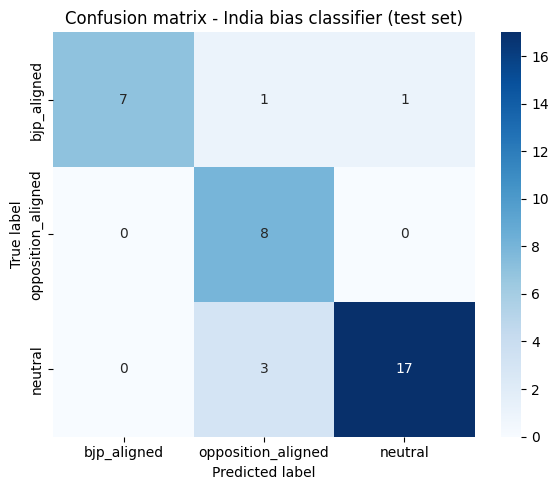

In [20]:
# Confusion matrix
# rows = true label, columns = predicted label
# a perfect classifier would have all counts on the diagonal
labels_ordered = ["bjp_aligned", "opposition_aligned", "neutral"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_ordered)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix - India bias classifier (test set)")
plt.tight_layout()
plt.show()

### Confidence score distribution and threshold derivation

The model outputs a confidence score (0-1) for every prediction. High confidence usually means the model is right. Low confidence usually means the article is ambiguous or the model is uncertain.

I want to find a threshold below which the error rate is too high. Predictions below that threshold get flagged as "uncertain" in the dashboard - shown with a grey/striped label rather than a hard bjp_aligned/opposition_aligned/neutral label.

**How to pick the threshold:** plot confidence distributions for correct and incorrect predictions. Find the confidence level where incorrect predictions start to dominate. That is the threshold.

Correct predictions:   32
Incorrect predictions: 5


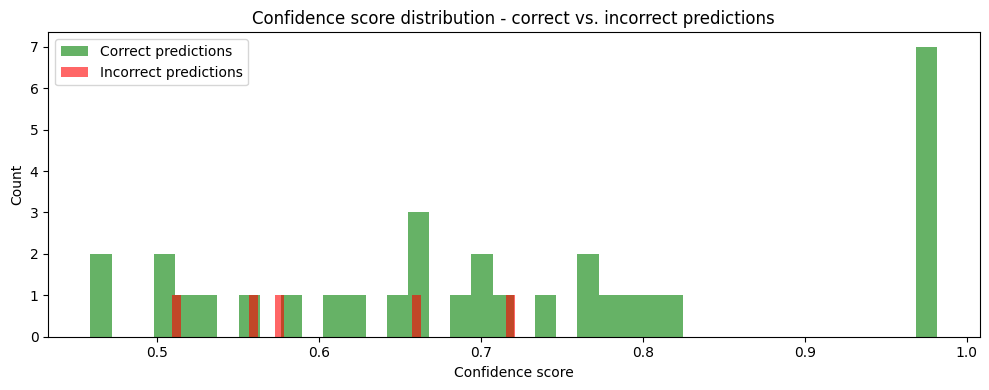

In [21]:
# separate confidence scores for correct vs. incorrect predictions
correct_mask = [p == t for p, t in zip(pred_labels, true_labels)]
correct_confs   = [c for c, ok in zip(confidences, correct_mask) if ok]
incorrect_confs = [c for c, ok in zip(confidences, correct_mask) if not ok]

print(f"Correct predictions:   {len(correct_confs):,}")
print(f"Incorrect predictions: {len(incorrect_confs):,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(correct_confs,   bins=40, alpha=0.6, color="green", label="Correct predictions")
ax.hist(incorrect_confs, bins=40, alpha=0.6, color="red",   label="Incorrect predictions")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.set_title("Confidence score distribution - correct vs. incorrect predictions")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# compute error rate in each confidence bin
# I want to find the confidence level where error rate drops to an acceptable level
bins = np.arange(0.0, 1.01, 0.05)  # bins from 0.0 to 1.0 in steps of 0.05
bin_labels  = []
bin_errors  = []
bin_totals  = []

for lo, hi in zip(bins[:-1], bins[1:]):
    in_bin = [
        (p == t)
        for p, t, c in zip(pred_labels, true_labels, confidences)
        if lo <= c < hi
    ]
    if len(in_bin) == 0:
        continue
    error_rate = 1 - (sum(in_bin) / len(in_bin))
    bin_labels.append(f"{lo:.2f}-{hi:.2f}")
    bin_errors.append(error_rate)
    bin_totals.append(len(in_bin))

print(f"{'Confidence bin':<15} {'Error rate':>12} {'N articles':>12}")
print("-" * 42)
for bl, er, nt in zip(bin_labels, bin_errors, bin_totals):
    flag = " <-- high error" if er > 0.35 else ""
    print(f"{bl:<15} {er:>11.1%} {nt:>12,}{flag}")

Confidence bin    Error rate   N articles
------------------------------------------
0.45-0.50              0.0%            3
0.50-0.55             25.0%            4
0.55-0.60             50.0%            4 <-- high error
0.60-0.65              0.0%            2
0.65-0.70             14.3%            7
0.70-0.75             25.0%            4
0.75-0.80              0.0%            4
0.80-0.85              0.0%            2
0.95-1.00              0.0%            7


In [23]:
# threshold derived from the error rate table above:
# below 0.85 the error rate stays above 29%, which is too high for a confident label
# at 0.85+, error rate drops to ~15% and below - that's the region worth trusting
CONFIDENCE_THRESHOLD = 0.85

trusted   = sum(1 for c in confidences if c >= CONFIDENCE_THRESHOLD)
uncertain = sum(1 for c in confidences if c <  CONFIDENCE_THRESHOLD)

trusted_correct = sum(
    1 for p, t, c in zip(pred_labels, true_labels, confidences)
    if c >= CONFIDENCE_THRESHOLD and p == t
)

print(f"Threshold: {CONFIDENCE_THRESHOLD}")
print(f"Trusted predictions   (conf >= {CONFIDENCE_THRESHOLD}): {trusted:,}   ({trusted/len(confidences)*100:.1f}%)")
print(f"Uncertain predictions (conf <  {CONFIDENCE_THRESHOLD}): {uncertain:,} ({uncertain/len(confidences)*100:.1f}%)")
print()
if trusted > 0:
    trusted_acc = trusted_correct / trusted
    print(f"Accuracy on trusted predictions: {trusted_acc:.4f} ({trusted_acc*100:.2f}%)")
print()
print(f"Use CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD} in src/classifier.py")

Threshold: 0.85
Trusted predictions   (conf >= 0.85): 7   (18.9%)
Uncertain predictions (conf <  0.85): 30 (81.1%)

Accuracy on trusted predictions: 1.0000 (100.00%)

Use CONFIDENCE_THRESHOLD = 0.85 in src/classifier.py
